# Task 3: Heart Disease Prediction

## Objective
Create a machine learning model to predict heart disease risk using the UCI Heart Disease dataset. We'll perform data exploration, preprocessing, model training, and evaluation.

## Dataset Description
The UCI Heart Disease dataset contains various clinical and demographic attributes to predict the presence of heart disease in patients. The target variable indicates whether a patient has heart disease (1) or not (0).

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Data Loading
Load the heart disease dataset and examine its basic properties.

In [2]:
# Load the dataset
df = pd.read_csv('heart_disease.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Display dataset info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
# Display statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## Data Cleaning
Detect and handle missing values in the dataset.

Missing values per column:
ca      4
thal    2
dtype: int64


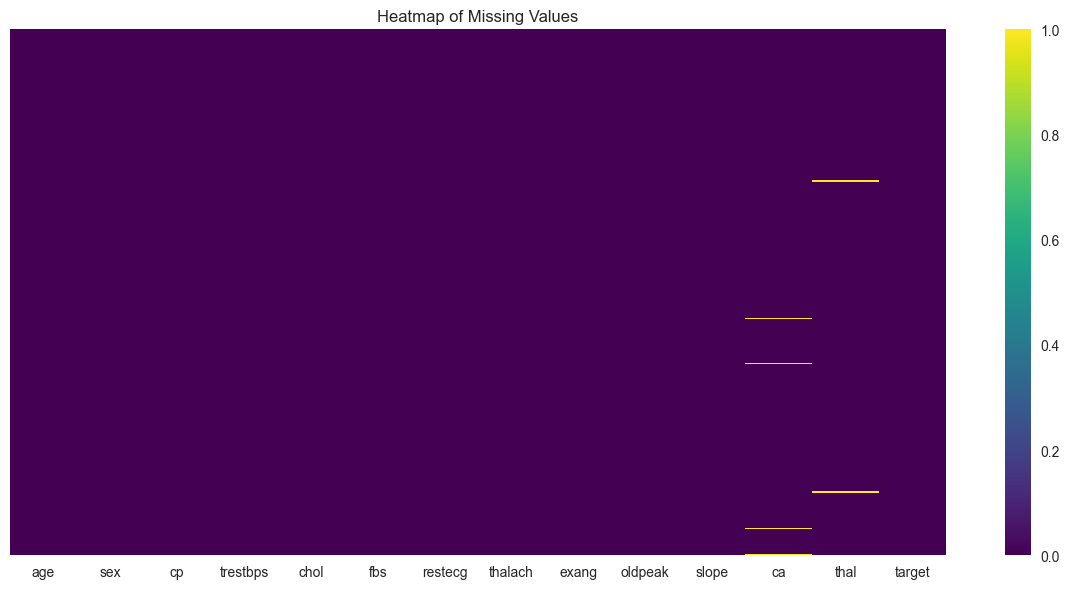

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.tight_layout()
plt.savefig('./figures/missing_values_heatmap.png')
plt.show()

In [6]:
# Handle missing values
# For numerical columns, fill with median
# For categorical columns, fill with mode
for column in df.columns:
    if df[column].isnull().sum() > 0:
        if df[column].dtype in ['int64', 'float64']:
            df[column] = df[column].fillna(df[column].median())
        else:
            df[column] = df[column].fillna(df[column].mode()[0])

# Verify no more missing values
print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


## Exploratory Data Analysis (EDA)
Perform exploratory analysis to understand the data patterns and relationships.

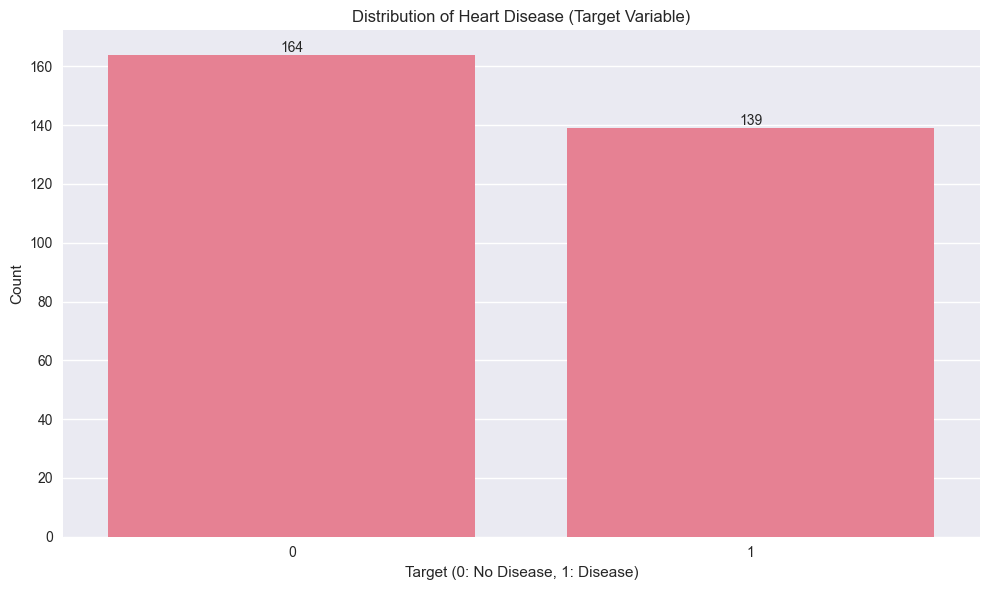

No Heart Disease: 164 (54.1%)
Heart Disease: 139 (45.9%)


In [7]:
# Target distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='target')
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Target (0: No Disease, 1: Disease)')
plt.ylabel('Count')

# Add count labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                       ha='center', va='bottom')
plt.tight_layout()
plt.savefig('./figures/target_distribution.png')
plt.show()

# Print percentage of each class
target_counts = df['target'].value_counts()
print(f"No Heart Disease: {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease: {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

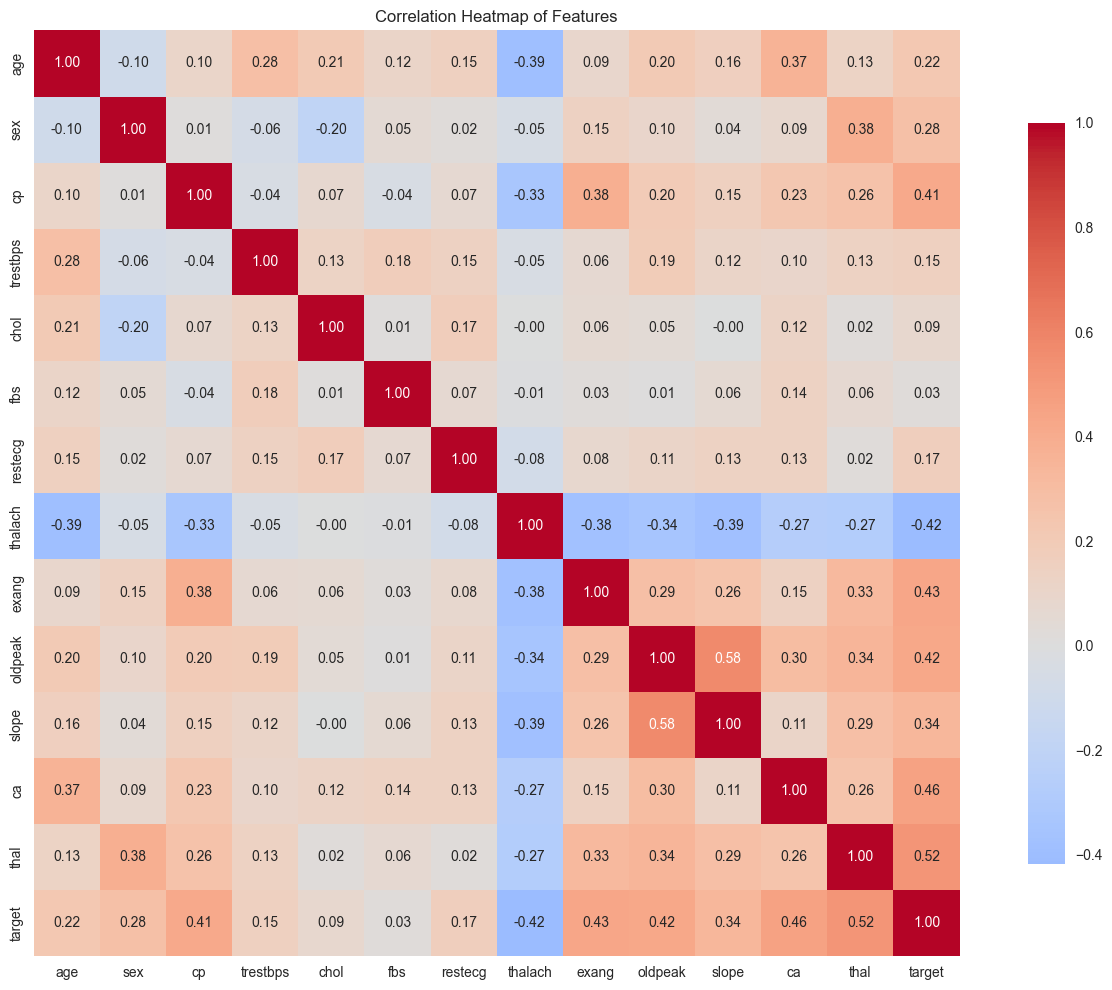

In [8]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.savefig('./figures/correlation_heatmap.png')
plt.show()

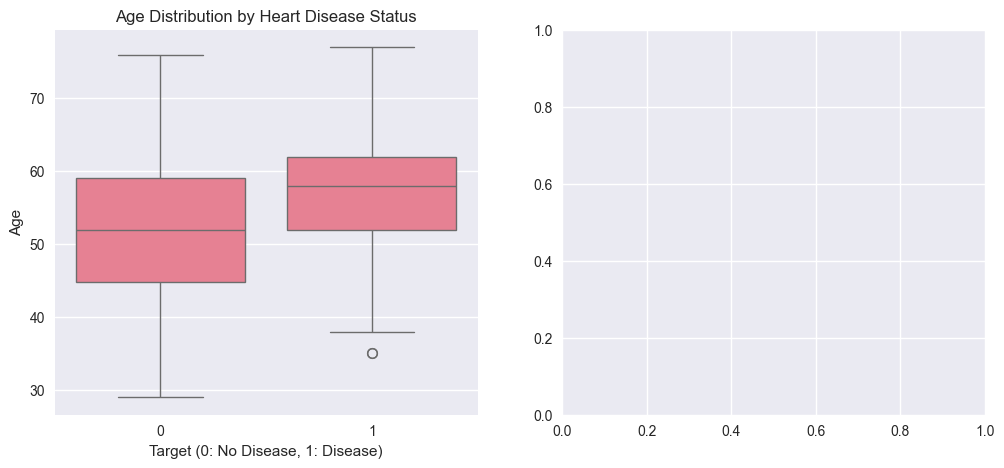

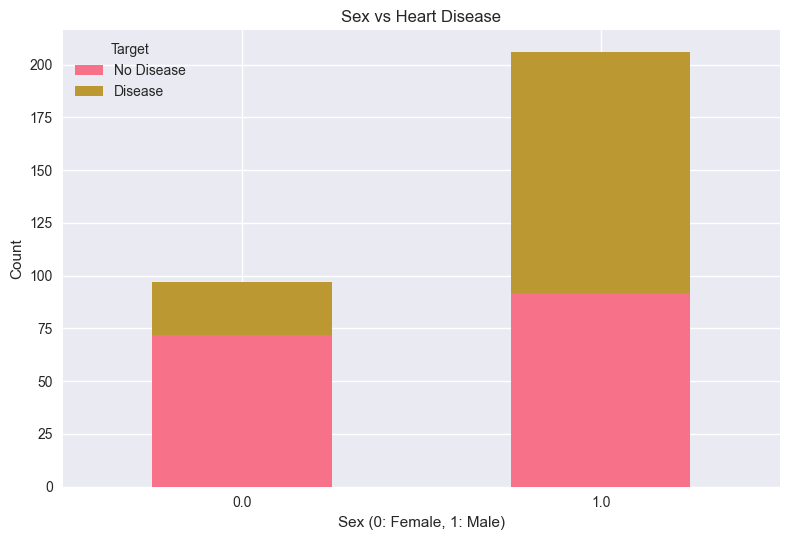

In [9]:
# Feature vs Target visualizations
# Age vs Target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='target', y='age')
plt.title('Age Distribution by Heart Disease Status')
plt.ylabel('Age')
plt.xlabel('Target (0: No Disease, 1: Disease)')

# Sex vs Target
plt.subplot(1, 2, 2)
pd.crosstab(df['sex'], df['target']).plot(kind='bar', stacked=True)
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex (0: Female, 1: Male)')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'], title='Target')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./figures/age_sex_vs_target.png')
plt.show()

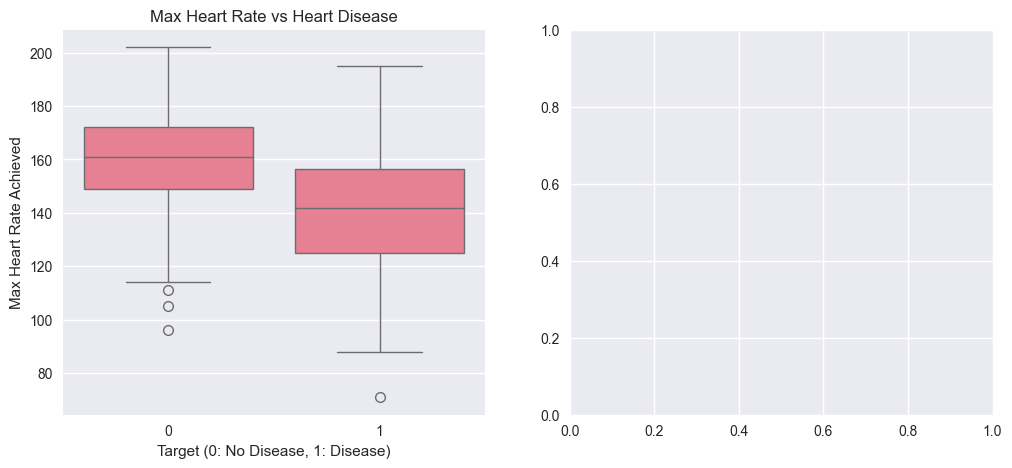

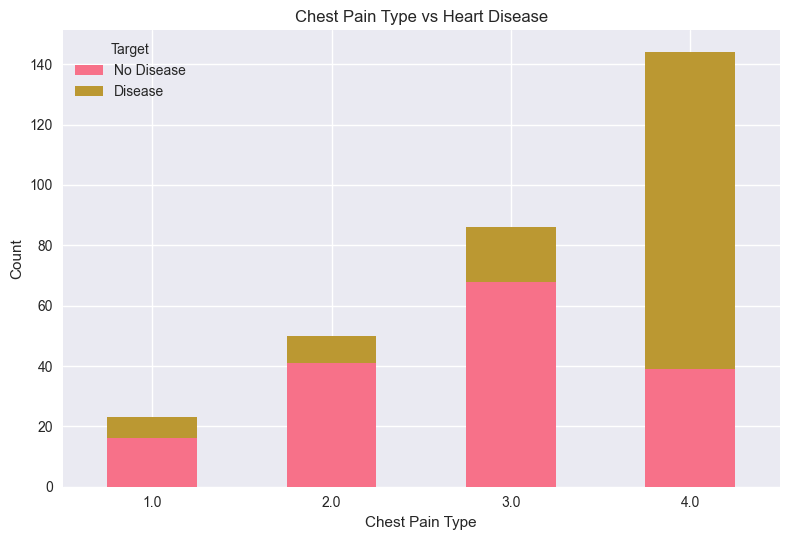

In [10]:
# Chest pain type vs Target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='target', y='thalach')  # Maximum heart rate achieved
plt.title('Max Heart Rate vs Heart Disease')
plt.ylabel('Max Heart Rate Achieved')
plt.xlabel('Target (0: No Disease, 1: Disease)')

plt.subplot(1, 2, 2)
pd.crosstab(df['cp'], df['target']).plot(kind='bar', stacked=True)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(['No Disease', 'Disease'], title='Target')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('./figures/chest_pain_max_hr_vs_target.png')
plt.show()

## Features & Target Separation
Separate the feature variables (X) and target variable (y).

In [11]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature names: {list(X.columns)}")

# Feature relevance explanation
feature_explanations = {
    'age': 'Patient age - higher age often correlates with increased heart disease risk',
    'sex': 'Gender - males historically have higher heart disease rates',
    'cp': 'Chest pain type - different types may indicate cardiac issues',
    'trestbps': 'Resting blood pressure - high BP is a risk factor',
    'chol': 'Cholesterol level - high cholesterol increases risk',
    'fbs': 'Fasting blood sugar - diabetes increases heart disease risk',
    'restecg': 'Resting ECG results - abnormalities may indicate issues',
    'thalach': 'Maximum heart rate achieved - lower max HR may indicate poor heart health',
    'exang': 'Exercise-induced angina - chest pain during exercise is a strong indicator',
    'oldpeak': 'ST depression induced by exercise - indicates heart stress',
    'slope': 'Slope of peak exercise ST segment - different slopes have different meanings',
    'ca': 'Number of major vessels colored by fluoroscopy - blocked arteries indicate disease',
    'thal': 'Thalassemia - blood disorder that can affect heart health'
}

print("\nFeature Explanations:")
for feature, explanation in feature_explanations.items():
    print(f"- {feature}: {explanation}")

Features shape: (303, 13)
Target shape: (303,)
Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Feature Explanations:
- age: Patient age - higher age often correlates with increased heart disease risk
- sex: Gender - males historically have higher heart disease rates
- cp: Chest pain type - different types may indicate cardiac issues
- trestbps: Resting blood pressure - high BP is a risk factor
- chol: Cholesterol level - high cholesterol increases risk
- fbs: Fasting blood sugar - diabetes increases heart disease risk
- restecg: Resting ECG results - abnormalities may indicate issues
- thalach: Maximum heart rate achieved - lower max HR may indicate poor heart health
- exang: Exercise-induced angina - chest pain during exercise is a strong indicator
- oldpeak: ST depression induced by exercise - indicates heart stress
- slope: Slope of peak exercise ST segment - different slopes have different meanings
- c

## Train-Test Split
Split the data into training and testing sets with an 80/20 split.

In [12]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts(normalize=True)}")
print(f"Testing target distribution: {y_test.value_counts(normalize=True)}")

Training set shape: (242, 13)
Testing set shape: (61, 13)
Training target distribution: target
0    0.541322
1    0.458678
Name: proportion, dtype: float64
Testing target distribution: target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## Model Training
Train a Logistic Regression model for heart disease prediction.

In [13]:
# Train Logistic Regression model
# Standardize features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")

# Model choice explanation
print("\nModel Choice Justification:")
print("Logistic Regression was chosen because:")
print("1. It's interpretable - we can understand which features contribute most")
print("2. It works well for binary classification problems like this")
print("3. It handles multiple features effectively")
print("4. It provides probability estimates for predictions")
print("5. It's less prone to overfitting compared to more complex models")

Logistic Regression model trained successfully!

Model Choice Justification:
Logistic Regression was chosen because:
1. It's interpretable - we can understand which features contribute most
2. It works well for binary classification problems like this
3. It handles multiple features effectively
4. It provides probability estimates for predictions
5. It's less prone to overfitting compared to more complex models


## Model Evaluation
Evaluate the model performance using accuracy, confusion matrix, and ROC-AUC.

Logistic Regression Accuracy: 0.8689 (86.89%)


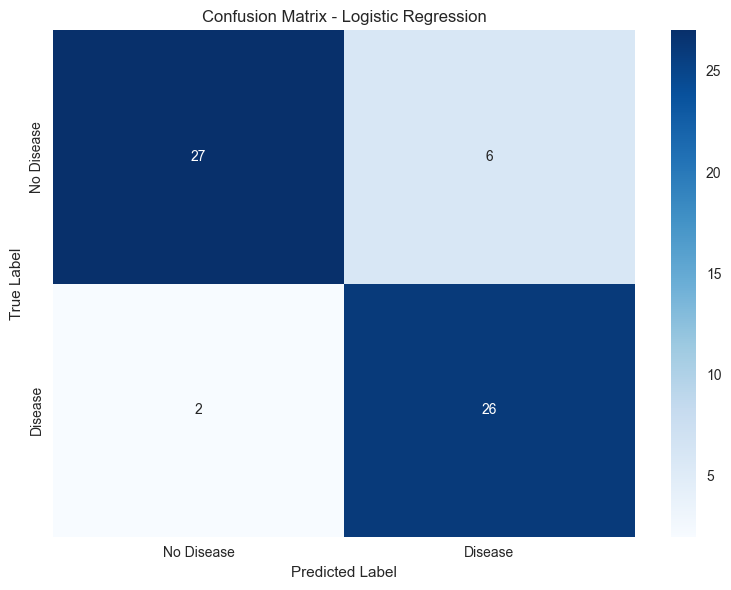

True Negatives: 27 (Correctly predicted no disease)
False Positives: 6 (Incorrectly predicted disease)
False Negatives: 2 (Incorrectly predicted no disease)
True Positives: 26 (Correctly predicted disease)


In [14]:
# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('./figures/confusion_matrix.png')
plt.show()

# Print confusion matrix details
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} (Correctly predicted no disease)")
print(f"False Positives: {fp} (Incorrectly predicted disease)")
print(f"False Negatives: {fn} (Incorrectly predicted no disease)")
print(f"True Positives: {tp} (Correctly predicted disease)")

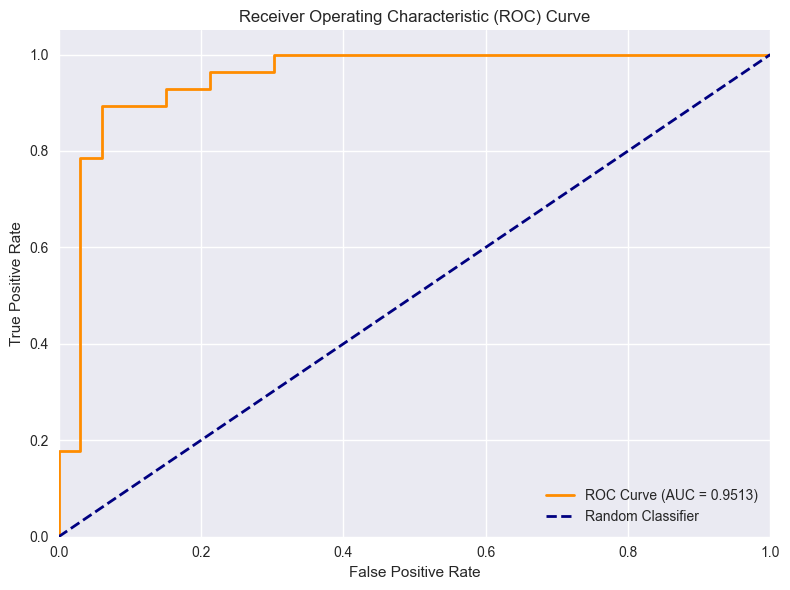

ROC AUC Score: 0.9513


In [15]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)
roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig('./figures/roc_curve.png')
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

## Feature Importance Analysis
Analyze which features are most important for predicting heart disease.

Feature Importance (based on Logistic Regression coefficients):
     feature  coefficient  abs_coefficient
11        ca     1.107898         1.107898
12      thal     0.677821         0.677821
1        sex     0.655563         0.655563
2         cp     0.543483         0.543483
8      exang     0.383642         0.383642
10     slope     0.354072         0.354072
7    thalach    -0.348486         0.348486
3   trestbps     0.313655         0.313655
5        fbs    -0.220560         0.220560
6    restecg     0.217329         0.217329
4       chol     0.215375         0.215375
9    oldpeak     0.149953         0.149953
0        age    -0.103159         0.103159


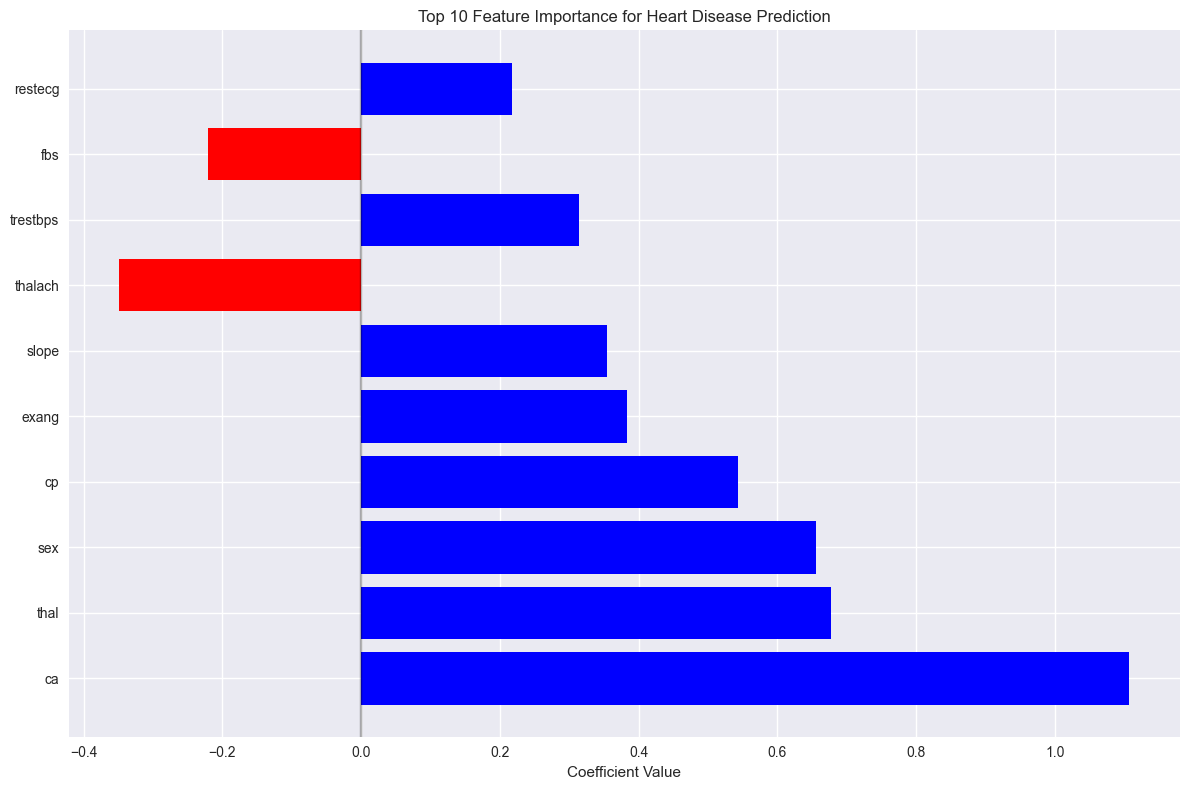


Interpretation of Top Features:
- ca: increases heart disease risk (coef: 1.108)
- thal: increases heart disease risk (coef: 0.678)
- sex: increases heart disease risk (coef: 0.656)
- cp: increases heart disease risk (coef: 0.543)
- exang: increases heart disease risk (coef: 0.384)


In [16]:
# Get feature importance from logistic regression coefficients
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values(by='abs_coefficient', ascending=False)

print("Feature Importance (based on Logistic Regression coefficients):")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)  # Top 10 features
colors = ['red' if coef < 0 else 'blue' for coef in top_features['coefficient']]
bars = plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Importance for Heart Disease Prediction')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('./figures/feature_importance.png')
plt.show()

# Print interpretation of top features
print("\nInterpretation of Top Features:")
for idx, row in feature_importance.head(5).iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"- {row['feature']}: {direction} heart disease risk (coef: {row['coefficient']:.3f})")

## Alternative Model: Decision Tree
Let's also train a Decision Tree model for comparison.

In [17]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"Decision Tree ROC AUC: {roc_auc_dt:.4f}")

# Feature importance for Decision Tree
dt_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nDecision Tree Feature Importance:")
print(dt_feature_importance.head())

Decision Tree Accuracy: 0.7869 (78.69%)
Decision Tree ROC AUC: 0.8047

Decision Tree Feature Importance:
   feature  importance
12    thal    0.378859
2       cp    0.151595
11      ca    0.116874
0      age    0.092980
4     chol    0.082157


## Results Summary
Summarize the findings and provide medical insights.

In [18]:
# Final results summary
print("=== HEART DISEASE PREDICTION RESULTS SUMMARY ===")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution: {dict(y.value_counts())}")
print(f"\nLogistic Regression Model:")
print(f"- Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"- ROC AUC: {roc_auc:.4f}")
print(f"\nDecision Tree Model:")
print(f"- Accuracy: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"- ROC AUC: {roc_auc_dt:.4f}")

print(f"\nTop 5 Most Important Features (Logistic Regression):")
for idx, row in feature_importance.head(5).iterrows():
    print(f"- {row['feature']}: coefficient = {row['coefficient']:.3f}")

print(f"\nTop 5 Most Important Features (Decision Tree):")
for idx, row in dt_feature_importance.head(5).iterrows():
    print(f"- {row['feature']}: importance = {row['importance']:.3f}")

# Medical insights
print(f"\n=== MEDICAL INSIGHTS ===")
print("Based on the analysis, the following factors appear to be important predictors of heart disease:")
print("1. Exercise-induced angina (exang) - chest pain during exercise")
print("2. Number of major vessels colored by fluoroscopy (ca) - indicates blocked arteries")
print("3. Maximum heart rate achieved (thalach) - lower max HR indicates poor heart health")
print("4. ST depression induced by exercise (oldpeak) - indicates heart stress")
print("5. Chest pain type (cp) - certain types are associated with cardiac issues")

print(f"\nIMPORTANT MEDICAL DISCLAIMER:")
print("This model is for educational purposes only and should not be used for actual medical diagnosis.")
print("Always consult with healthcare professionals for proper medical assessment and diagnosis.")

=== HEART DISEASE PREDICTION RESULTS SUMMARY ===
Dataset shape: (303, 14)
Target distribution: {0: np.int64(164), 1: np.int64(139)}

Logistic Regression Model:
- Accuracy: 0.8689 (86.89%)
- ROC AUC: 0.9513

Decision Tree Model:
- Accuracy: 0.7869 (78.69%)
- ROC AUC: 0.8047

Top 5 Most Important Features (Logistic Regression):
- ca: coefficient = 1.108
- thal: coefficient = 0.678
- sex: coefficient = 0.656
- cp: coefficient = 0.543
- exang: coefficient = 0.384

Top 5 Most Important Features (Decision Tree):
- thal: importance = 0.379
- cp: importance = 0.152
- ca: importance = 0.117
- age: importance = 0.093
- chol: importance = 0.082

=== MEDICAL INSIGHTS ===
Based on the analysis, the following factors appear to be important predictors of heart disease:
1. Exercise-induced angina (exang) - chest pain during exercise
2. Number of major vessels colored by fluoroscopy (ca) - indicates blocked arteries
3. Maximum heart rate achieved (thalach) - lower max HR indicates poor heart health
4. 